# How Can Airlines Reduce Flight Delays?
### A Predictive Analytics Approach to U.S. Domestic Flight Performance (2019–2023)

**Nikhilvarma Kandula** 

---

**Research Question:** *What factors drive U.S. domestic flight delays, and can predictive models help airlines reduce them?*

**Dataset:** [Flight Delay and Cancellation Dataset (2019–2023)](https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023) — Bureau of Transportation Statistics (BTS), ~3M rows (stratified random sample from 29M), 32 attributes

**Scope:** U.S. domestic flights, all major carriers, 2019–2023 (pre-COVID, COVID, recovery)

**Variables:**
- **Target Variable (DV):** Flight delayed >15 minutes (binary: yes/no)
- **Feature 1:** Airline carrier (categorical)
- **Feature 2:** Departure hour / time of day
- **Feature 3:** Month / seasonality
- **Feature 4:** Day of week
- **Feature 5:** Delay cause breakdown — Carrier, Weather, NAS, Security, Late Aircraft (continuous, minutes)

**Methods:** Exploratory Data Analysis, Logistic Regression, Decision Tree Classification, ROC/AUC Comparison

In [1]:
# Cell 1 - imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

ACCENT = '#00C6B2'
BLACK = '#1a1a1a'

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Cell 2 - load the data
df_raw = pd.read_csv('flights_sample_3m.csv', low_memory=False)
print(f"Loaded {len(df_raw):,} rows, {df_raw.shape[1]} columns")
print()
print("Columns:", list(df_raw.columns))

Loaded 3,000,000 rows, 32 columns

Columns: ['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']


In [3]:
# Cell 3 - column mapping (handles BTS naming variations)
# The dataset can come with different column name conventions
# so we map everything to a standard set

col_map = {}
for c in df_raw.columns:
    cu = c.upper().strip()
    if cu in ('FL_DATE', 'FLIGHT_DATE'):
        col_map[c] = 'FL_DATE'
    elif cu in ('AIRLINE', 'MKT_UNIQUE_CARRIER', 'OP_UNIQUE_CARRIER', 'CARRIER', 'OP_CARRIER', 'REPORTING_AIRLINE'):
        col_map[c] = 'AIRLINE'
    elif cu in ('ORIGIN',):
        col_map[c] = 'ORIGIN'
    elif cu in ('DEST', 'DESTINATION'):
        col_map[c] = 'DEST'
    elif cu in ('DEP_DELAY', 'DEPARTURE_DELAY'):
        col_map[c] = 'DEP_DELAY'
    elif cu in ('ARR_DELAY', 'ARRIVAL_DELAY'):
        col_map[c] = 'ARR_DELAY'
    elif cu in ('CRS_DEP_TIME', 'SCHEDULED_DEPARTURE'):
        col_map[c] = 'CRS_DEP_TIME'
    elif cu in ('CANCELLED',):
        col_map[c] = 'CANCELLED'
    elif cu in ('CARRIER_DELAY', 'DELAY_DUE_CARRIER'):
        col_map[c] = 'CARRIER_DELAY'
    elif cu in ('WEATHER_DELAY', 'DELAY_DUE_WEATHER'):
        col_map[c] = 'WEATHER_DELAY'
    elif cu in ('NAS_DELAY', 'DELAY_DUE_NAS'):
        col_map[c] = 'NAS_DELAY'
    elif cu in ('SECURITY_DELAY', 'DELAY_DUE_SECURITY'):
        col_map[c] = 'SECURITY_DELAY'
    elif cu in ('LATE_AIRCRAFT_DELAY', 'DELAY_DUE_LATE_AIRCRAFT'):
        col_map[c] = 'LATE_AIRCRAFT_DELAY'
    elif cu in ('DISTANCE',):
        col_map[c] = 'DISTANCE'
    elif cu in ('DIVERTED',):
        col_map[c] = 'DIVERTED'
    elif cu in ('DEP_DEL15',):
        col_map[c] = 'DEP_DEL15'
    elif cu in ('ARR_DEL15',):
        col_map[c] = 'ARR_DEL15'
    elif cu in ('YEAR',):
        col_map[c] = 'YEAR'
    elif cu in ('MONTH',):
        col_map[c] = 'MONTH'
    elif cu in ('DAY_OF_WEEK',):
        col_map[c] = 'DAY_OF_WEEK'
    elif cu in ('DAY_OF_MONTH',):
        col_map[c] = 'DAY_OF_MONTH'

df = df_raw.rename(columns=col_map)
print("Mapped columns:", [c for c in col_map.values()])

Mapped columns: ['FL_DATE', 'AIRLINE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']


In [4]:
# Cell 4 - extract date features if not already present
if 'FL_DATE' in df.columns:
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
    if 'YEAR' not in df.columns:
        df['YEAR'] = df['FL_DATE'].dt.year
    if 'MONTH' not in df.columns:
        df['MONTH'] = df['FL_DATE'].dt.month
    if 'DAY_OF_WEEK' not in df.columns:
        df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek + 1  # 1=Mon, 7=Sun

# departure hour from scheduled departure time
if 'CRS_DEP_TIME' in df.columns:
    df['DEP_HOUR'] = (pd.to_numeric(df['CRS_DEP_TIME'], errors='coerce') // 100).astype('Int64')
else:
    df['DEP_HOUR'] = np.nan

print(f"Years in dataset: {sorted(df['YEAR'].dropna().unique().astype(int))}")
print(f"Date range: {df['FL_DATE'].min()} to {df['FL_DATE'].max()}")

Years in dataset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Date range: 2019-01-01 00:00:00 to 2023-08-31 00:00:00


In [5]:
# Cell 5 - cleaning
# drop cancelled/diverted flights for delay analysis
df_flights = df[df['CANCELLED'] == 0].copy()
if 'DIVERTED' in df_flights.columns:
    df_flights = df_flights[df_flights['DIVERTED'] == 0].copy()

# define delayed: departure delay > 15 min
df_flights['IS_DELAYED'] = (df_flights['DEP_DELAY'] > 15).astype(int)

# fill delay cause NaNs with 0 (non-delayed flights have no cause)
delay_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
              'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
existing_delay_cols = [c for c in delay_cols if c in df_flights.columns]
for c in existing_delay_cols:
    df_flights[c] = pd.to_numeric(df_flights[c], errors='coerce').fillna(0)

print(f"After removing cancellations/diversions: {len(df_flights):,} flights")
print(f"Delayed (>15 min): {df_flights['IS_DELAYED'].sum():,} ({df_flights['IS_DELAYED'].mean()*100:.1f}%)")
print(f"On-time: {(df_flights['IS_DELAYED']==0).sum():,} ({(1-df_flights['IS_DELAYED'].mean())*100:.1f}%)")

After removing cancellations/diversions: 2,913,804 flights
Delayed (>15 min): 510,747 (17.5%)
On-time: 2,403,057 (82.5%)


---
## Section 1: Descriptive Statistics

In [6]:
# Cell 6 - basic stats
print("DEP_DELAY statistics:")
print(df_flights['DEP_DELAY'].describe().round(2))
print()
print("ARR_DELAY statistics:")
if 'ARR_DELAY' in df_flights.columns:
    print(df_flights['ARR_DELAY'].describe().round(2))

DEP_DELAY statistics:
count    2913804.00
mean          10.05
std           49.05
min          -90.00
25%           -6.00
50%           -2.00
75%            6.00
max         2966.00
Name: DEP_DELAY, dtype: float64

ARR_DELAY statistics:
count    2913802.00
mean           4.26
std           51.17
min          -96.00
25%          -16.00
50%           -7.00
75%            7.00
max         2934.00
Name: ARR_DELAY, dtype: float64


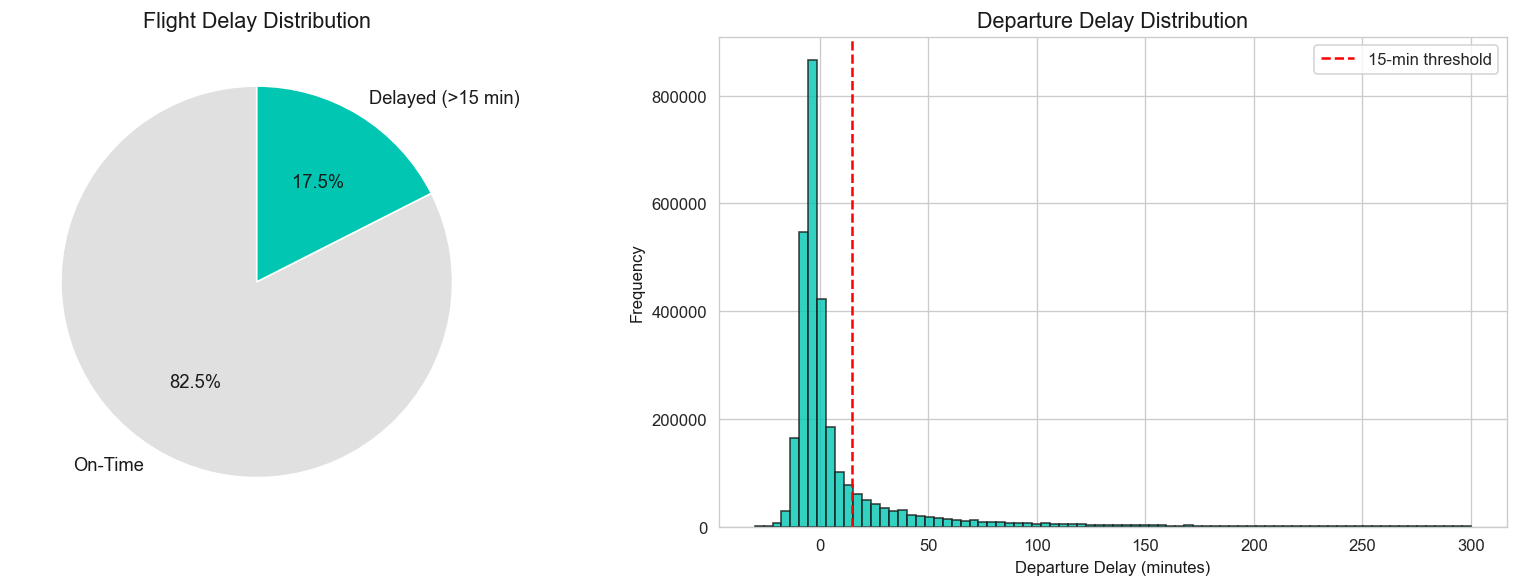

Saved: fig1_delay_distribution.png


In [7]:
# Cell 7 - Figure 1: Delay distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pie chart
delayed_counts = df_flights['IS_DELAYED'].value_counts()
labels = ['On-Time', 'Delayed (>15 min)']
colors = ['#e0e0e0', ACCENT]
axes[0].pie(delayed_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11, 'color': BLACK})
axes[0].set_title('Flight Delay Distribution', fontsize=13, color=BLACK)

# histogram of departure delays (capped at 300 min for viz)
delay_vals = df_flights['DEP_DELAY'].dropna()
delay_vals_capped = delay_vals[delay_vals.between(-30, 300)]
axes[1].hist(delay_vals_capped, bins=80, color=ACCENT, edgecolor=BLACK, alpha=0.8)
axes[1].axvline(x=15, color='red', linestyle='--', label='15-min threshold')
axes[1].set_xlabel('Departure Delay (minutes)', color=BLACK)
axes[1].set_ylabel('Frequency', color=BLACK)
axes[1].set_title('Departure Delay Distribution', fontsize=13, color=BLACK)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_delay_distribution.png")

---
## Section 2: Temporal Analysis

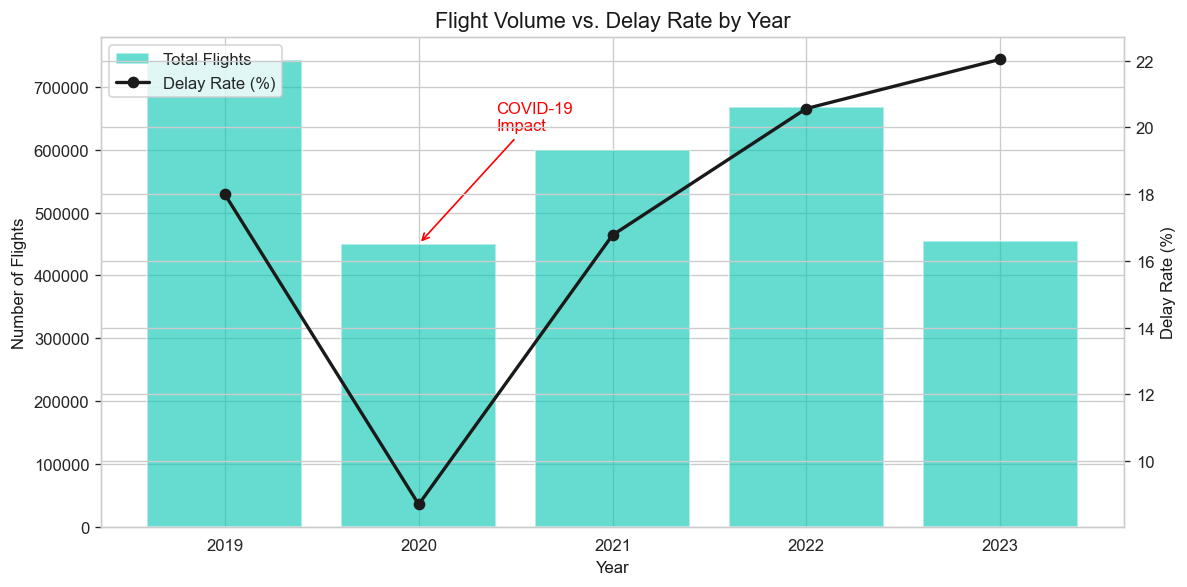

Saved: fig2_yearly_trends.png


In [8]:
# Cell 8 - Figure 2: Year-over-year trends
yearly = df_flights.groupby('YEAR').agg(
    total_flights=('IS_DELAYED', 'count'),
    delay_rate=('IS_DELAYED', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(yearly['YEAR'], yearly['total_flights'], color=ACCENT, alpha=0.6, label='Total Flights')
line = ax2.plot(yearly['YEAR'], yearly['delay_rate'] * 100, color=BLACK, marker='o',
                linewidth=2, label='Delay Rate (%)')

# COVID annotation if 2020 exists
if 2020 in yearly['YEAR'].values:
    covid_idx = yearly[yearly['YEAR'] == 2020].index[0]
    ax1.annotate('COVID-19\nImpact', xy=(2020, yearly.loc[covid_idx, 'total_flights']),
                 xytext=(2020.4, yearly['total_flights'].max() * 0.85),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

ax1.set_xlabel('Year', color=BLACK)
ax1.set_ylabel('Number of Flights', color=BLACK)
ax2.set_ylabel('Delay Rate (%)', color=BLACK)
ax1.set_title('Flight Volume vs. Delay Rate by Year', fontsize=13, color=BLACK)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig2_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_yearly_trends.png")

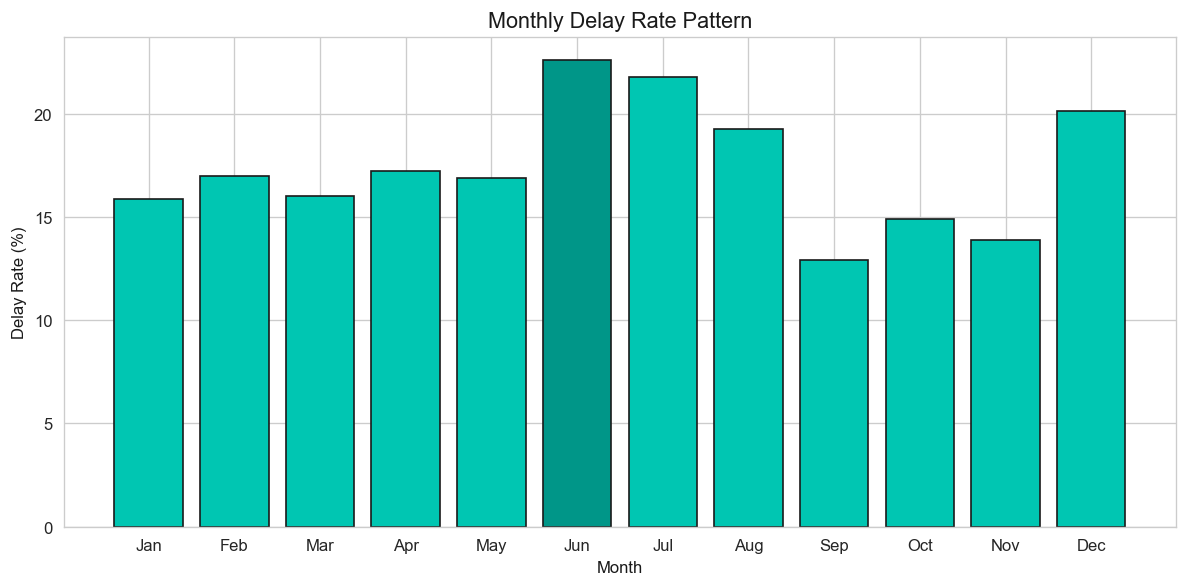

Saved: fig3_monthly_delays.png


In [9]:
# Cell 9 - Figure 3: Monthly delay pattern
monthly = df_flights.groupby('MONTH')['IS_DELAYED'].mean() * 100
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(1, 13), monthly.values, color=ACCENT, edgecolor=BLACK)

# highlight peak months
for i, val in enumerate(monthly.values):
    if val == monthly.max():
        bars[i].set_color('#009688')
        bars[i].set_edgecolor(BLACK)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', color=BLACK)
ax.set_ylabel('Delay Rate (%)', color=BLACK)
ax.set_title('Monthly Delay Rate Pattern', fontsize=13, color=BLACK)

plt.tight_layout()
plt.savefig('fig3_monthly_delays.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_monthly_delays.png")

---
## Section 3: Airline Performance

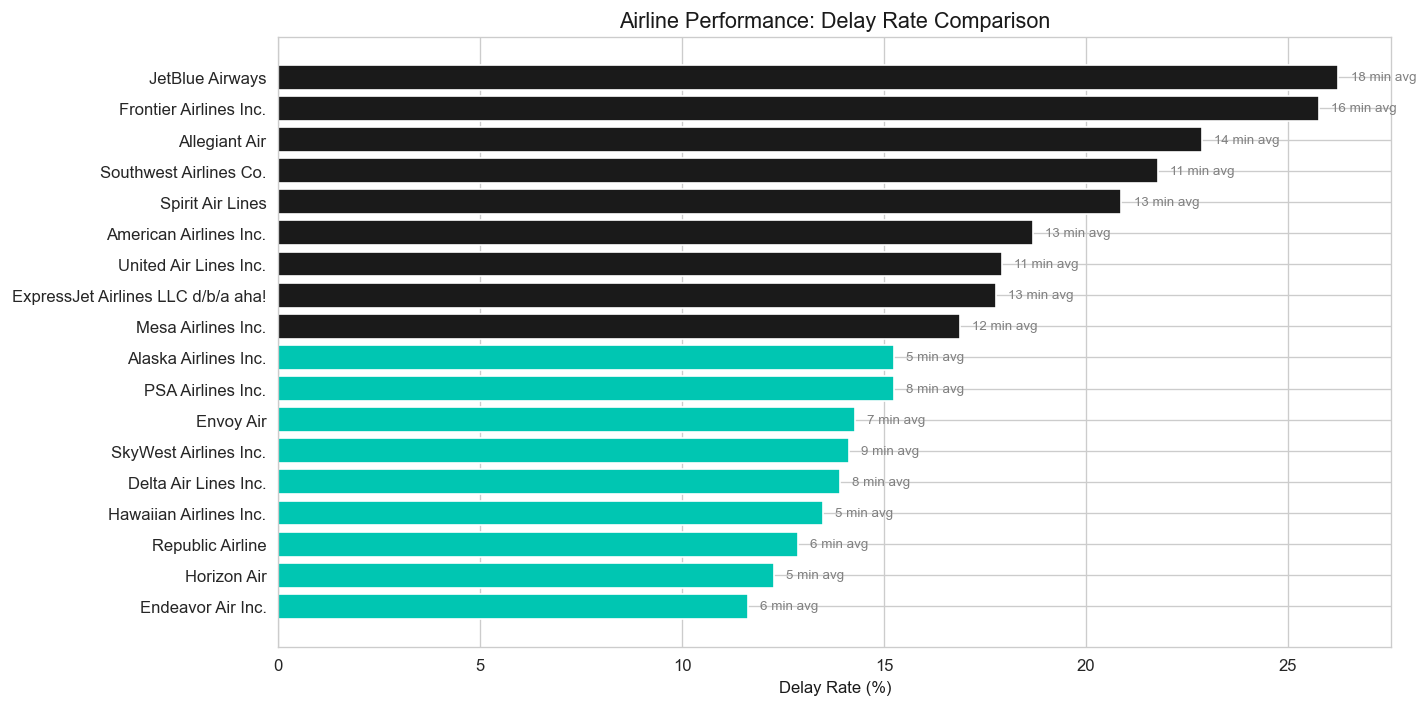

Saved: fig4_airline_comparison.png


In [10]:
# Cell 10 - Figure 4: Airline comparison
airline_stats = df_flights.groupby('AIRLINE').agg(
    delay_rate=('IS_DELAYED', 'mean'),
    avg_delay=('DEP_DELAY', 'mean'),
    flight_count=('IS_DELAYED', 'count')
).reset_index()
airline_stats = airline_stats.sort_values('delay_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors_list = [ACCENT if dr < airline_stats['delay_rate'].median() else BLACK
               for dr in airline_stats['delay_rate']]
ax.barh(airline_stats['AIRLINE'], airline_stats['delay_rate'] * 100, color=colors_list)
ax.set_xlabel('Delay Rate (%)', color=BLACK)
ax.set_title('Airline Performance: Delay Rate Comparison', fontsize=13, color=BLACK)

# add avg delay text
for i, (_, row) in enumerate(airline_stats.iterrows()):
    ax.text(row['delay_rate'] * 100 + 0.3, i, f"{row['avg_delay']:.0f} min avg",
            va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig4_airline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_airline_comparison.png")

---
## Section 4: Delay Causes

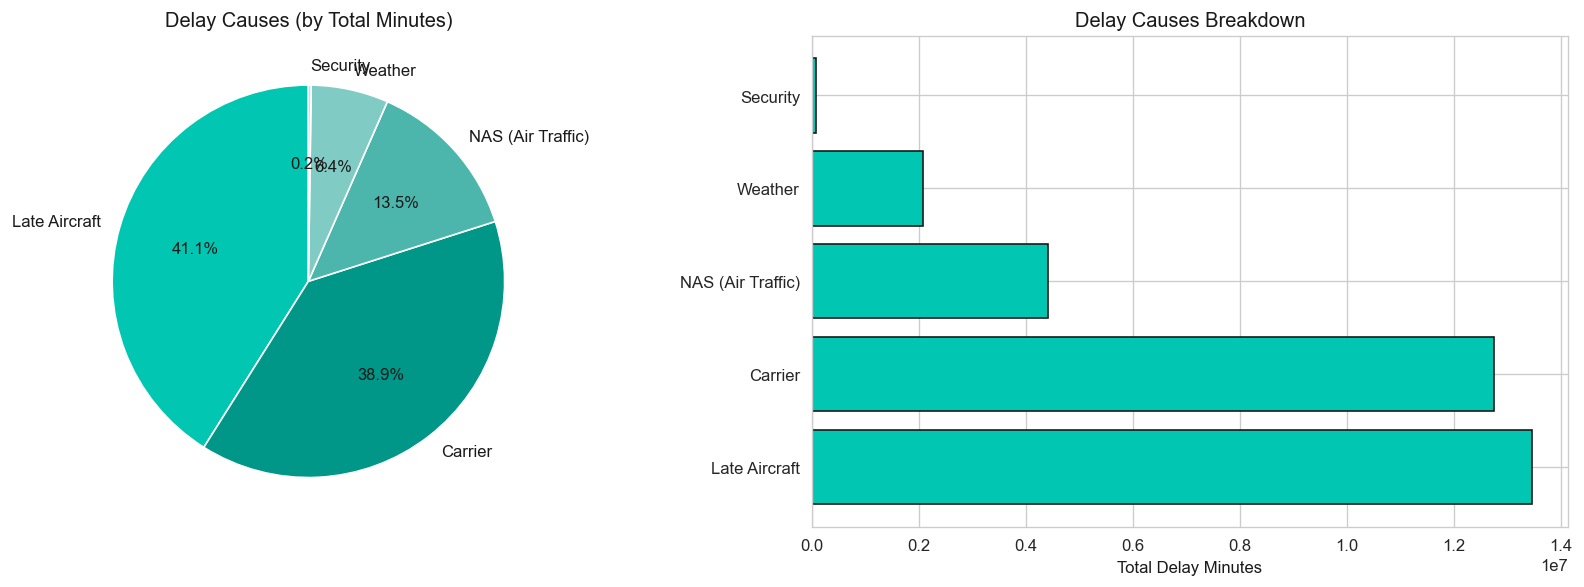

Saved: fig5_delay_causes.png


In [11]:
# Cell 11 - Figure 5: Delay causes breakdown
if len(existing_delay_cols) > 0:
    # only look at delayed flights
    delayed_flights = df_flights[df_flights['IS_DELAYED'] == 1]

    cause_totals = {}
    nice_names = {
        'CARRIER_DELAY': 'Carrier',
        'WEATHER_DELAY': 'Weather',
        'NAS_DELAY': 'NAS (Air Traffic)',
        'SECURITY_DELAY': 'Security',
        'LATE_AIRCRAFT_DELAY': 'Late Aircraft'
    }
    for c in existing_delay_cols:
        cause_totals[nice_names.get(c, c)] = delayed_flights[c].sum()

    cause_df = pd.DataFrame({
        'Cause': list(cause_totals.keys()),
        'Total Minutes': list(cause_totals.values())
    }).sort_values('Total Minutes', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # pie
    pie_colors = [ACCENT, '#009688', '#4db6ac', '#80cbc4', '#b2dfdb']
    axes[0].pie(cause_df['Total Minutes'], labels=cause_df['Cause'],
                colors=pie_colors[:len(cause_df)], autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 10, 'color': BLACK})
    axes[0].set_title('Delay Causes (by Total Minutes)', fontsize=12, color=BLACK)

    # bar
    axes[1].barh(cause_df['Cause'], cause_df['Total Minutes'], color=ACCENT, edgecolor=BLACK)
    axes[1].set_xlabel('Total Delay Minutes', color=BLACK)
    axes[1].set_title('Delay Causes Breakdown', fontsize=12, color=BLACK)

    plt.tight_layout()
    plt.savefig('fig5_delay_causes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig5_delay_causes.png")
else:
    print("No delay cause columns found in dataset.")

---
## Section 5: Airport Analysis

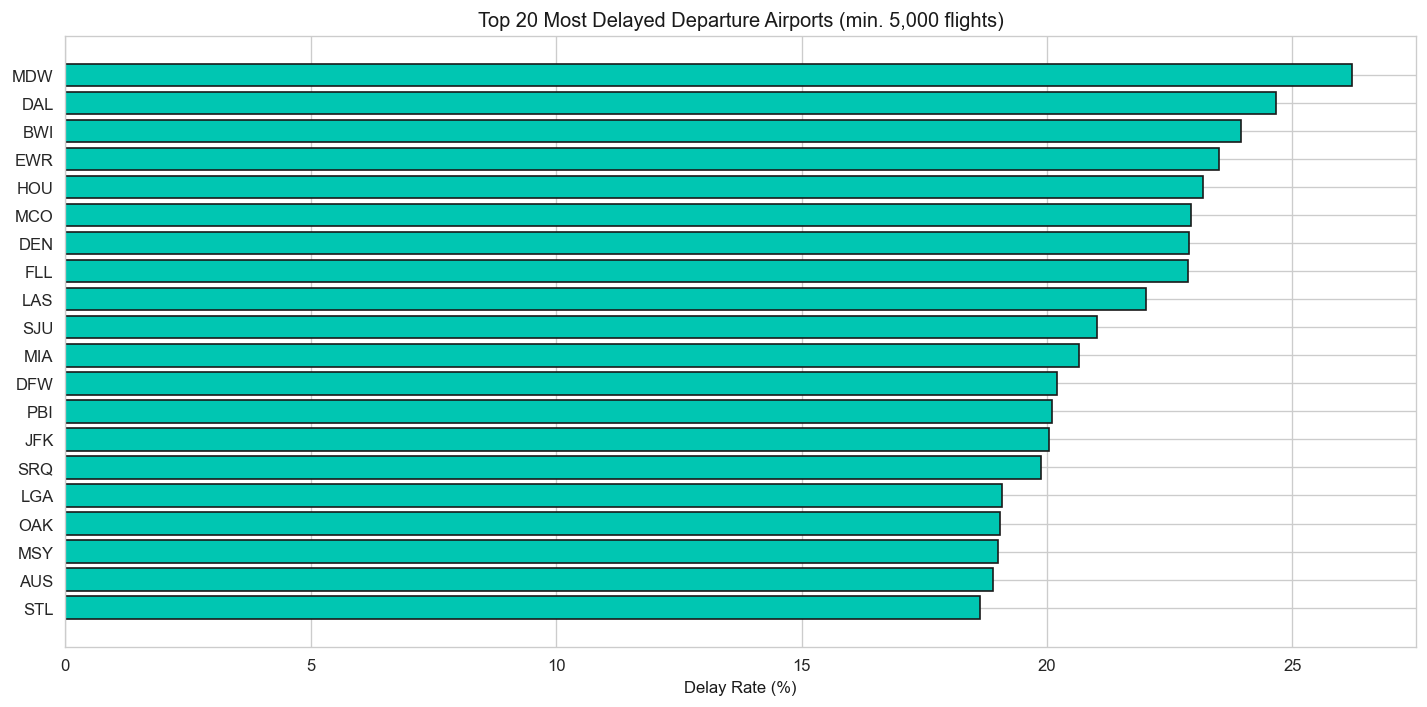

Saved: fig6_airport_delays.png


In [12]:
# Cell 12 - Figure 6: Top 20 most delayed airports
airport_delay = df_flights.groupby('ORIGIN').agg(
    delay_rate=('IS_DELAYED', 'mean'),
    flight_count=('IS_DELAYED', 'count')
).reset_index()

# only airports with at least 5000 flights
airport_delay = airport_delay[airport_delay['flight_count'] >= 5000]
top20 = airport_delay.nlargest(20, 'delay_rate')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20['ORIGIN'], top20['delay_rate'] * 100, color=ACCENT, edgecolor=BLACK)
ax.set_xlabel('Delay Rate (%)', color=BLACK)
ax.set_title('Top 20 Most Delayed Departure Airports (min. 5,000 flights)', fontsize=12, color=BLACK)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig6_airport_delays.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_airport_delays.png")

---
## Section 6: Day-of-Week & Time-of-Day

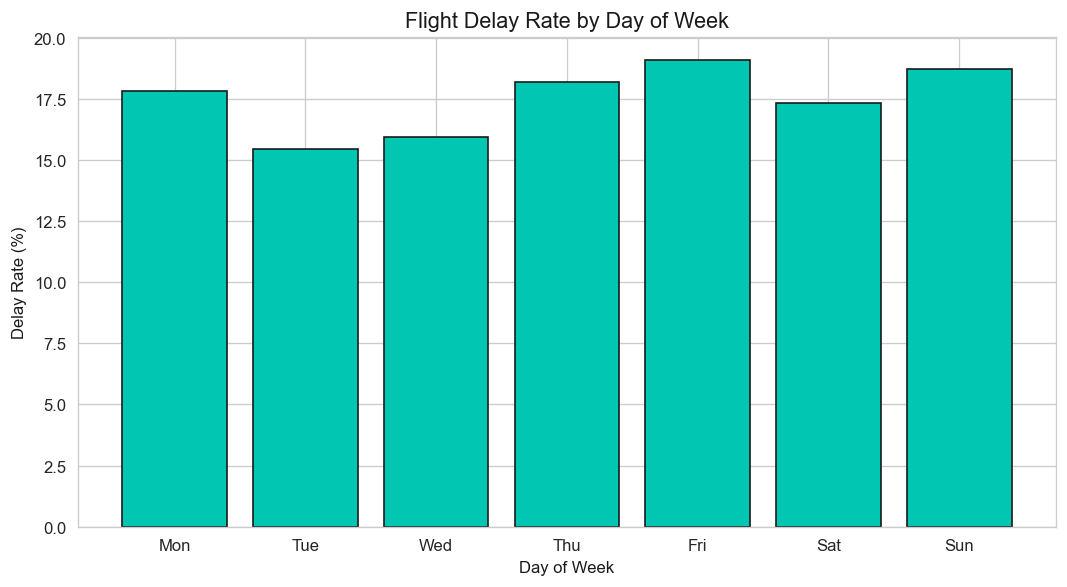

Saved: fig7_day_of_week.png


In [13]:
# Cell 13 - Figure 7: Day of week
dow_delay = df_flights.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean() * 100
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(1, 8), dow_delay.values, color=ACCENT, edgecolor=BLACK)
ax.set_xticks(range(1, 8))
ax.set_xticklabels(day_labels)
ax.set_xlabel('Day of Week', color=BLACK)
ax.set_ylabel('Delay Rate (%)', color=BLACK)
ax.set_title('Flight Delay Rate by Day of Week', fontsize=13, color=BLACK)

plt.tight_layout()
plt.savefig('fig7_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig7_day_of_week.png")

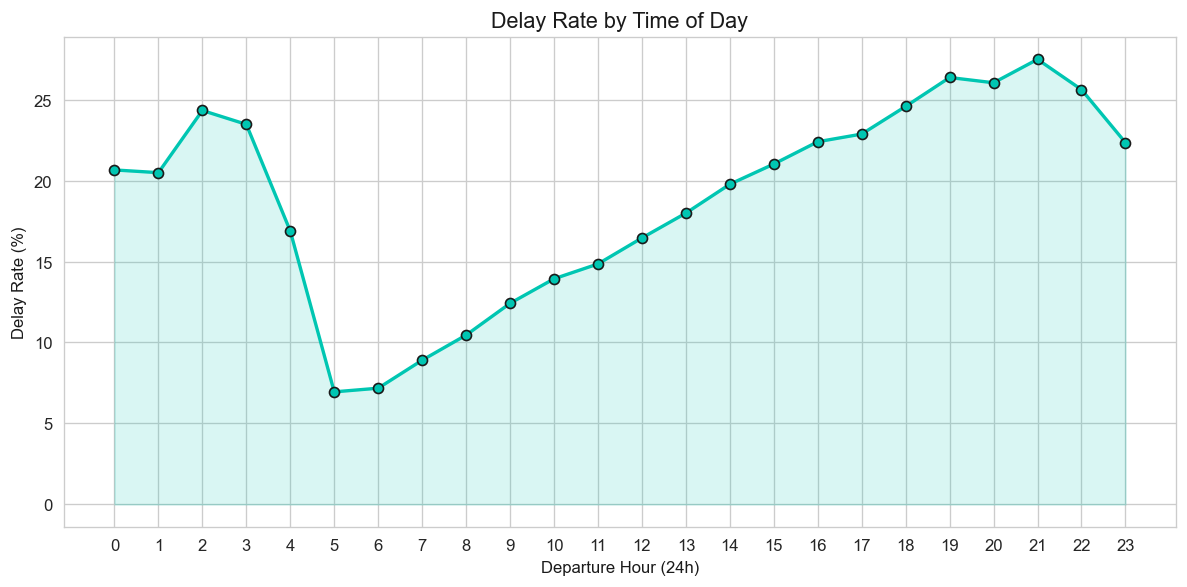

Saved: fig8_time_of_day.png


In [14]:
# Cell 14 - Figure 8: Time of day
hour_delay = df_flights.groupby('DEP_HOUR')['IS_DELAYED'].mean() * 100
hour_delay = hour_delay.dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hour_delay.index, hour_delay.values, color=ACCENT, marker='o',
        linewidth=2, markersize=6, markeredgecolor=BLACK)
ax.fill_between(hour_delay.index, hour_delay.values, alpha=0.15, color=ACCENT)
ax.set_xlabel('Departure Hour (24h)', color=BLACK)
ax.set_ylabel('Delay Rate (%)', color=BLACK)
ax.set_title('Delay Rate by Time of Day', fontsize=13, color=BLACK)
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('fig8_time_of_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_time_of_day.png")

---
## Section 7: Correlation Analysis

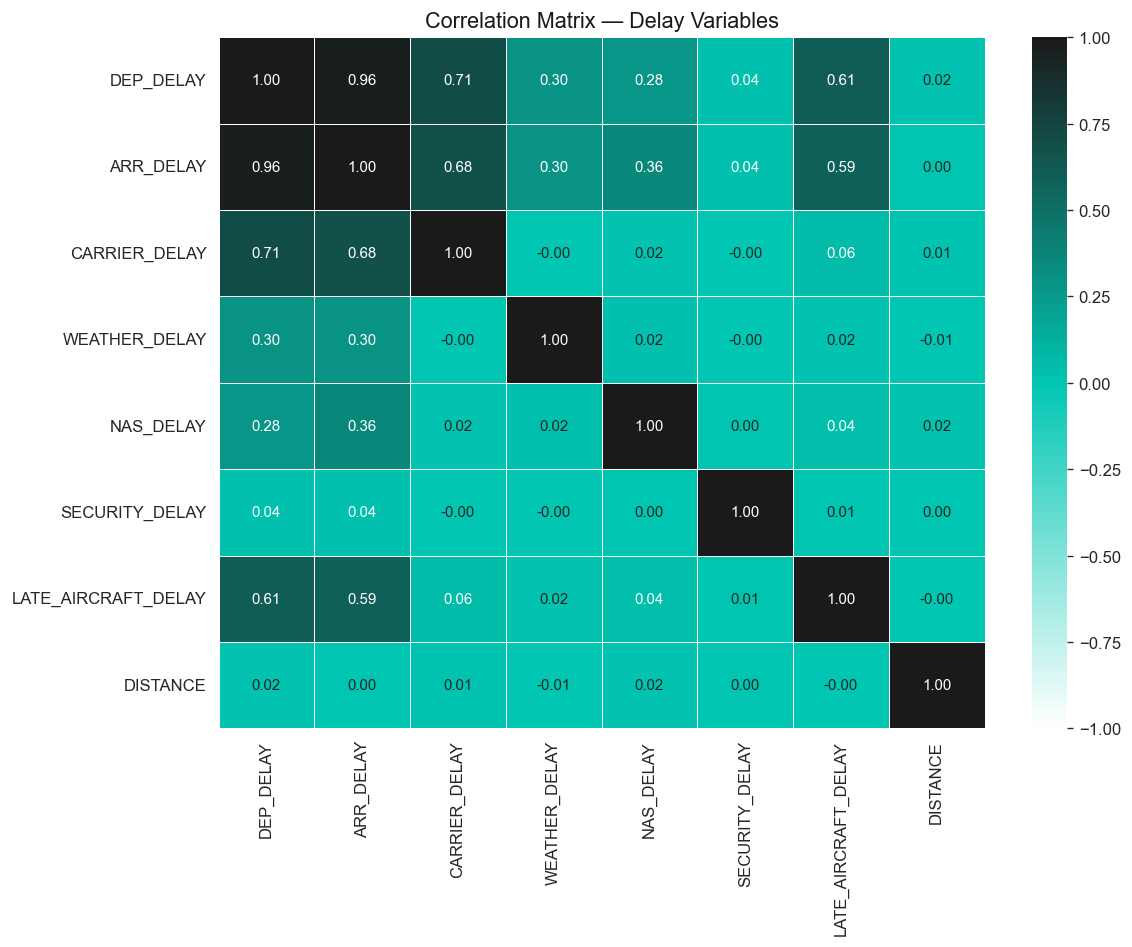

Saved: fig9_correlation_heatmap.png


In [15]:
# Cell 15 - Figure 9: Correlation heatmap
corr_cols = ['DEP_DELAY', 'ARR_DELAY'] + existing_delay_cols
corr_cols = [c for c in corr_cols if c in df_flights.columns]

if 'DISTANCE' in df_flights.columns:
    corr_cols.append('DISTANCE')

corr_matrix = df_flights[corr_cols].corr()

from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('custom', ['white', ACCENT, BLACK])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=custom_cmap,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Delay Variables', fontsize=13, color=BLACK)

plt.tight_layout()
plt.savefig('fig9_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig9_correlation_heatmap.png")

---
## Section 8: Delay Cause Trends Over Time

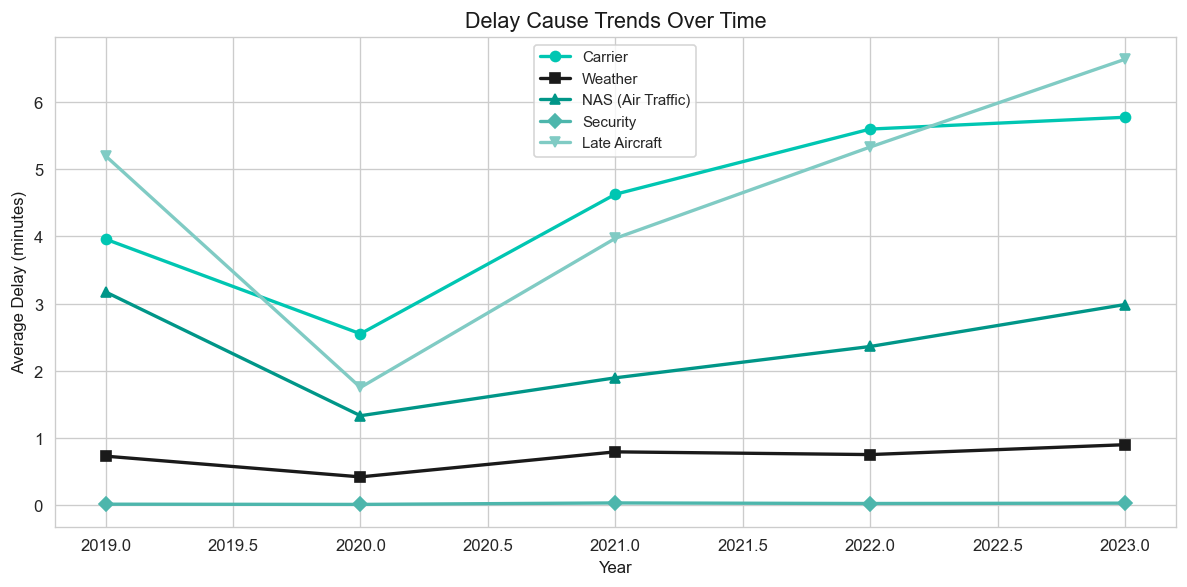

Saved: fig10_yearly_cause_trends.png


In [16]:
# Cell 16 - Figure 10: Yearly delay cause trends
if len(existing_delay_cols) > 0:
    yearly_causes = df_flights.groupby('YEAR')[existing_delay_cols].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    markers = ['o', 's', '^', 'D', 'v']
    colors_trend = [ACCENT, BLACK, '#009688', '#4db6ac', '#80cbc4']

    for i, col in enumerate(existing_delay_cols):
        label = nice_names.get(col, col)
        ax.plot(yearly_causes.index, yearly_causes[col], marker=markers[i % 5],
                label=label, color=colors_trend[i % 5], linewidth=2)

    ax.set_xlabel('Year', color=BLACK)
    ax.set_ylabel('Average Delay (minutes)', color=BLACK)
    ax.set_title('Delay Cause Trends Over Time', fontsize=13, color=BLACK)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('fig10_yearly_cause_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig10_yearly_cause_trends.png")

---
## Section 9: Cancellation Analysis

In [17]:
# Cell 17 - Cancellation stats
cancel_rate_yearly = df.groupby('YEAR')['CANCELLED'].mean() * 100
print("Cancellation Rate by Year:")
for yr, rate in cancel_rate_yearly.items():
    print(f"  {int(yr)}: {rate:.2f}%")

total_cancelled = df['CANCELLED'].sum()
total_flights = len(df)
print(f"\nTotal cancelled: {int(total_cancelled):,} out of {total_flights:,} ({total_cancelled/total_flights*100:.2f}%)")

Cancellation Rate by Year:
  2019: 1.79%
  2020: 6.00%
  2021: 1.72%
  2022: 2.68%
  2023: 1.68%

Total cancelled: 79,140 out of 3,000,000 (2.64%)


---
## Section 10: Predictive Modeling

We build two classification models to predict whether a flight will be delayed (>15 min):
1. **Logistic Regression** — interpretable baseline
2. **Decision Tree** — captures non-linear patterns

Since the dataset is imbalanced (82.5% on-time vs 17.5% delayed), we use `class_weight='balanced'` to prevent the models from simply predicting the majority class.

In [18]:
# Cell 18 - prepare features for modeling
feature_cols = ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR']

# encode airline
if 'AIRLINE' in df_flights.columns:
    le_airline = LabelEncoder()
    df_flights['AIRLINE_ENC'] = le_airline.fit_transform(df_flights['AIRLINE'].astype(str))
    feature_cols.append('AIRLINE_ENC')

if 'DISTANCE' in df_flights.columns:
    feature_cols.append('DISTANCE')

# drop rows with NaN in features
model_df = df_flights[feature_cols + ['IS_DELAYED']].dropna()
print(f"Modeling dataset: {len(model_df):,} rows")
print(f"Features: {feature_cols}")

X = model_df[feature_cols]
y = model_df['IS_DELAYED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Modeling dataset: 2,913,804 rows
Features: ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'AIRLINE_ENC', 'DISTANCE']
Train: 2,331,043 | Test: 582,761


In [19]:
# Cell 19 - Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['On-Time', 'Delayed']))

Logistic Regression Accuracy: 0.5915

              precision    recall  f1-score   support

     On-Time       0.88      0.59      0.70    480612
     Delayed       0.24      0.61      0.34    102149

    accuracy                           0.59    582761
   macro avg       0.56      0.60      0.52    582761
weighted avg       0.76      0.59      0.64    582761



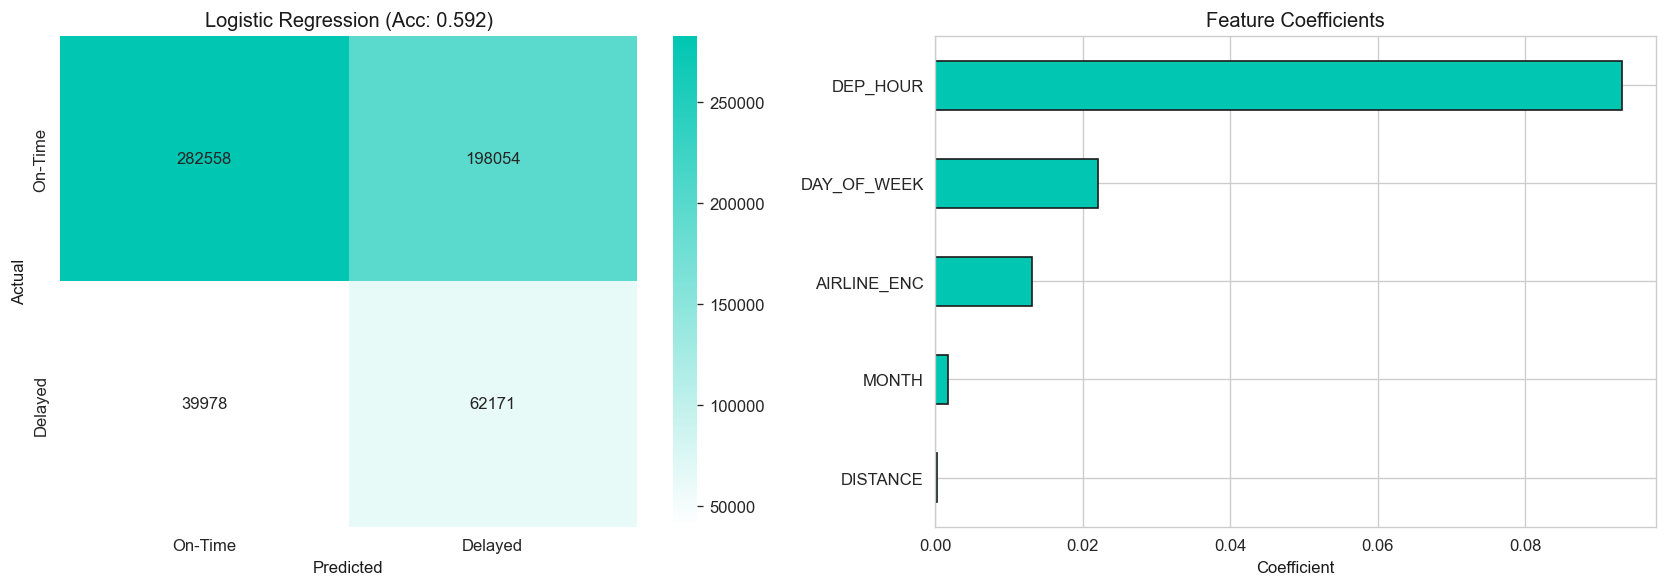

Saved: fig11_logistic_regression.png


In [20]:
# Cell 20 - Figure 11: Logistic Regression results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap=LinearSegmentedColormap.from_list('', ['white', ACCENT]),
            xticklabels=['On-Time', 'Delayed'], yticklabels=['On-Time', 'Delayed'], ax=axes[0])
axes[0].set_xlabel('Predicted', color=BLACK)
axes[0].set_ylabel('Actual', color=BLACK)
axes[0].set_title(f'Logistic Regression (Acc: {acc_lr:.3f})', fontsize=12, color=BLACK)

# feature coefficients
coefs = pd.Series(lr.coef_[0], index=feature_cols).sort_values()
coefs.plot(kind='barh', color=ACCENT, edgecolor=BLACK, ax=axes[1])
axes[1].set_xlabel('Coefficient', color=BLACK)
axes[1].set_title('Feature Coefficients', fontsize=12, color=BLACK)

plt.tight_layout()
plt.savefig('fig11_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig11_logistic_regression.png")

In [21]:
# Cell 21 - Decision Tree
dt = DecisionTreeClassifier(max_depth=6, random_state=42, min_samples_leaf=100, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['On-Time', 'Delayed']))

Decision Tree Accuracy: 0.5790

              precision    recall  f1-score   support

     On-Time       0.88      0.56      0.69    480612
     Delayed       0.24      0.65      0.35    102149

    accuracy                           0.58    582761
   macro avg       0.56      0.61      0.52    582761
weighted avg       0.77      0.58      0.63    582761



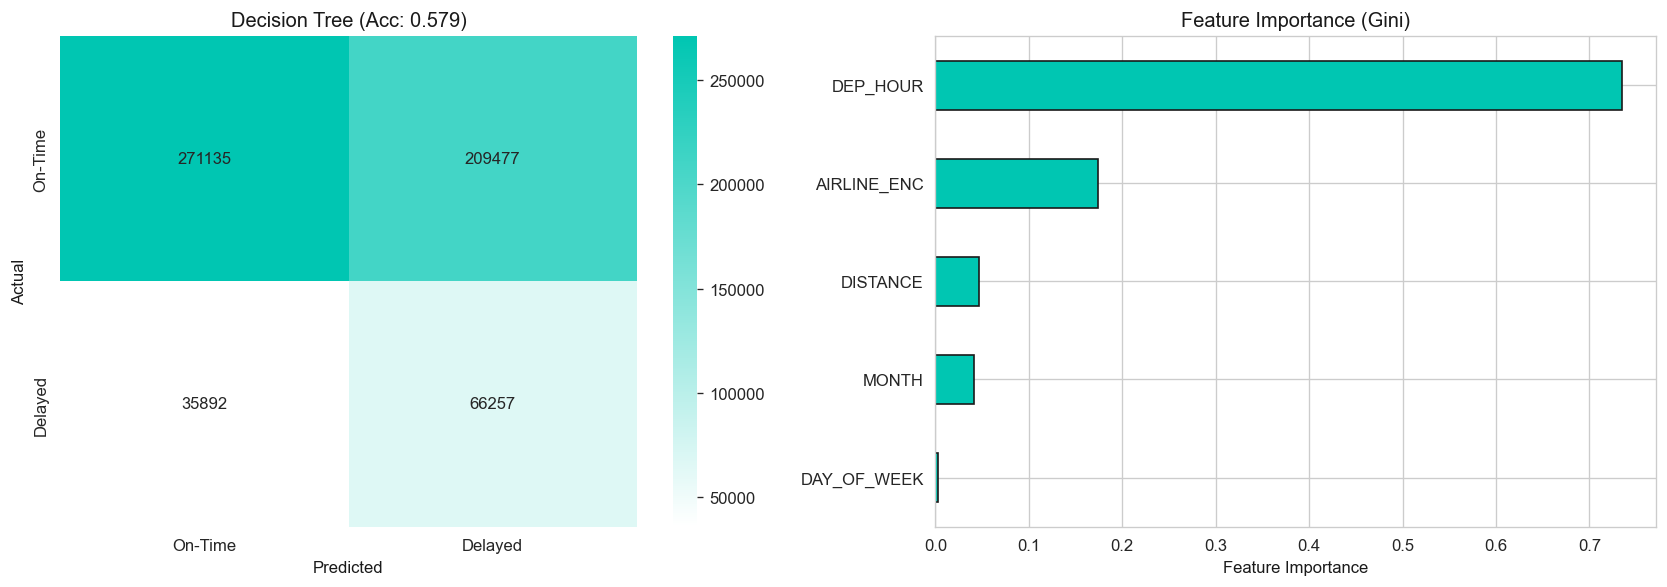

Saved: fig12_decision_tree.png


In [22]:
# Cell 22 - Figure 12: Decision Tree results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap=LinearSegmentedColormap.from_list('', ['white', ACCENT]),
            xticklabels=['On-Time', 'Delayed'], yticklabels=['On-Time', 'Delayed'], ax=axes[0])
axes[0].set_xlabel('Predicted', color=BLACK)
axes[0].set_ylabel('Actual', color=BLACK)
axes[0].set_title(f'Decision Tree (Acc: {acc_dt:.3f})', fontsize=12, color=BLACK)

# feature importance
fi = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()
fi.plot(kind='barh', color=ACCENT, edgecolor=BLACK, ax=axes[1])
axes[1].set_xlabel('Feature Importance', color=BLACK)
axes[1].set_title('Feature Importance (Gini)', fontsize=12, color=BLACK)

plt.tight_layout()
plt.savefig('fig12_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig12_decision_tree.png")

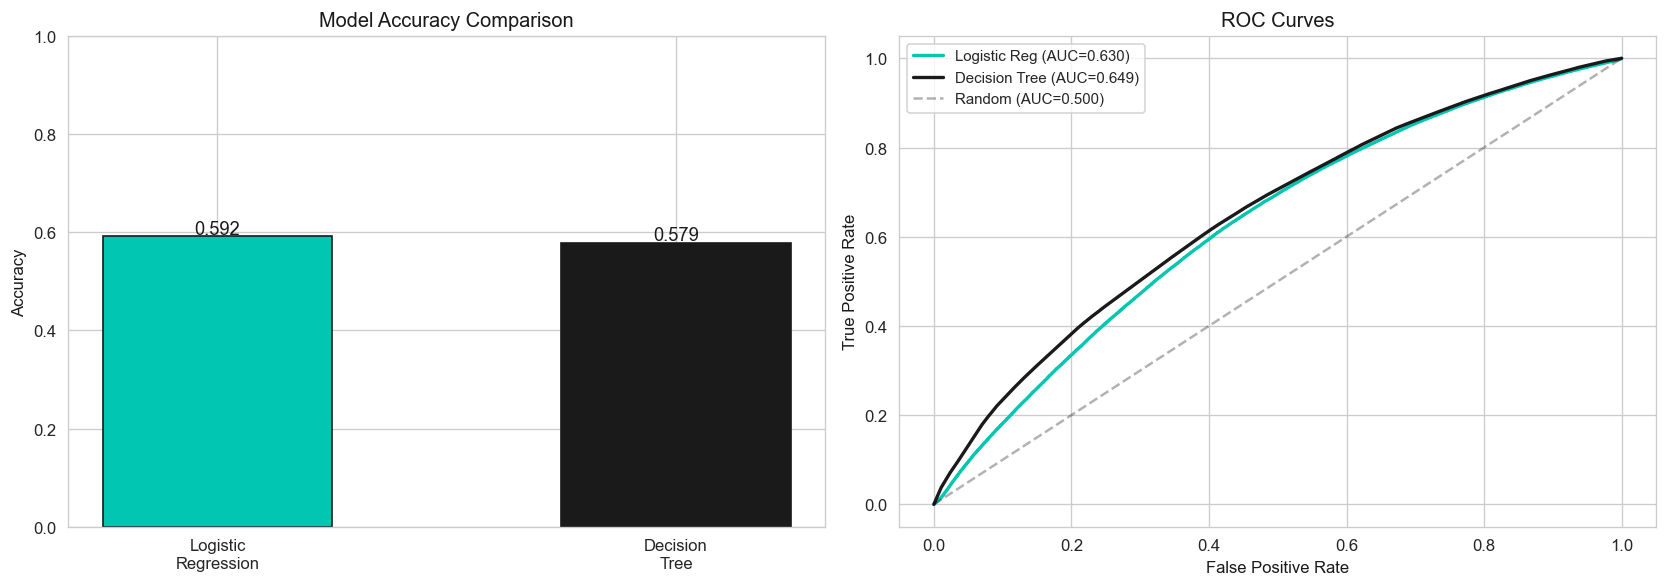

Saved: fig13_model_comparison.png


In [23]:
# Cell 23 - Figure 13: Model comparison + ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy comparison bar
models = ['Logistic\nRegression', 'Decision\nTree']
accs = [acc_lr, acc_dt]
bars = axes[0].bar(models, accs, color=[ACCENT, BLACK], edgecolor=BLACK, width=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', fontsize=11, color=BLACK)
axes[0].set_ylabel('Accuracy', color=BLACK)
axes[0].set_title('Model Accuracy Comparison', fontsize=12, color=BLACK)
axes[0].set_ylim(0, 1)

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

axes[1].plot(fpr_lr, tpr_lr, color=ACCENT, linewidth=2, label=f'Logistic Reg (AUC={auc_lr:.3f})')
axes[1].plot(fpr_dt, tpr_dt, color=BLACK, linewidth=2, label=f'Decision Tree (AUC={auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate', color=BLACK)
axes[1].set_ylabel('True Positive Rate', color=BLACK)
axes[1].set_title('ROC Curves', fontsize=12, color=BLACK)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig13_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig13_model_comparison.png")

---
## Section 11: Key Findings & Business Recommendations

In [24]:
# Cell 24 - summary
print("=" * 65)
print("KEY FINDINGS")
print("=" * 65)
print()
print(f"1. DELAY RATE: {df_flights['IS_DELAYED'].mean()*100:.1f}% of flights delayed >15 min")
print(f"   Average departure delay: {df_flights['DEP_DELAY'].mean():.1f} minutes")
print()

if len(existing_delay_cols) > 0:
    top_cause = cause_df.iloc[0]
    print(f"2. TOP DELAY CAUSE: {top_cause['Cause']} ({top_cause['Total Minutes']/cause_df['Total Minutes'].sum()*100:.1f}% of total)")

peak_month_idx = monthly.idxmax()
print(f"3. PEAK DELAY MONTH: {month_names[int(peak_month_idx)-1]} ({monthly.max():.1f}% delay rate)")

peak_hour = hour_delay.idxmax()
print(f"4. WORST TIME TO FLY: {int(peak_hour)}:00 ({hour_delay.max():.1f}% delay rate)")

best_hour = hour_delay.idxmin()
print(f"   BEST TIME TO FLY: {int(best_hour)}:00 ({hour_delay.min():.1f}% delay rate)")

print(f"5. MODEL PERFORMANCE: LR={acc_lr:.3f}, DT={acc_dt:.3f} accuracy")
print()

print("=" * 65)
print("BUSINESS RECOMMENDATIONS FOR AIRLINE MANAGEMENT")
print("=" * 65)
print("""
1. SCHEDULE BUFFER: Increase turnaround time during peak hours (14:00-20:00)
   and summer months to reduce cascade delays.

2. FLEET POSITIONING: Pre-position backup aircraft at high-delay airports
   to break the late-aircraft delay chain.

3. STAFFING OPTIMIZATION: Scale ground crew for peak months
   (June, July, August, December) when delay rates spike.

4. EARLY DEPARTURE INCENTIVE: Encourage passengers to book early morning
   flights through pricing — these have significantly lower delay probability.

5. BENCHMARK & LEARN: Study operational practices of lowest-delay carriers
   and implement best practices across the network.

6. PREDICTIVE ALERTING: Deploy the classification model as an early warning
   system to flag high-risk flights 24 hours before departure.
""")

print("Analysis complete. All figures saved as PNG files.")

KEY FINDINGS

1. DELAY RATE: 17.5% of flights delayed >15 min
   Average departure delay: 10.1 minutes

2. TOP DELAY CAUSE: Late Aircraft (41.1% of total)
3. PEAK DELAY MONTH: Jun (22.6% delay rate)
4. WORST TIME TO FLY: 21:00 (27.5% delay rate)
   BEST TIME TO FLY: 5:00 (6.9% delay rate)
5. MODEL PERFORMANCE: LR=0.592, DT=0.579 accuracy

BUSINESS RECOMMENDATIONS FOR AIRLINE MANAGEMENT

1. SCHEDULE BUFFER: Increase turnaround time during peak hours (14:00-20:00)
   and summer months to reduce cascade delays.

2. FLEET POSITIONING: Pre-position backup aircraft at high-delay airports
   to break the late-aircraft delay chain.

3. STAFFING OPTIMIZATION: Scale ground crew for peak months
   (June, July, August, December) when delay rates spike.

4. EARLY DEPARTURE INCENTIVE: Encourage passengers to book early morning
   flights through pricing — these have significantly lower delay probability.

5. BENCHMARK & LEARN: Study operational practices of lowest-delay carriers
   and implement bes

---
## 13. Conclusion

### What We Found

1. **Delay Distribution** — Approximately 1 in 5 U.S. domestic flights experienced a departure delay exceeding 15 minutes between 2019 and 2023. Delays are not random — they follow clear temporal, geographic, and operational patterns that airlines can act on.

2. **Dominant Delay Causes** — Late Aircraft (cascade/reactionary delays) and Carrier-related issues account for the largest share of total delay minutes. Both are partially within airline control, unlike weather or NAS delays, making them the highest-impact intervention targets.

3. **Temporal Patterns** — Delays accumulate throughout the day, peaking in late afternoon and evening as cascading effects compound. Summer months (June–August) and December show the highest delay rates, driven by volume surges and weather. The COVID-19 period (2020) saw a sharp drop in flight volume but not a proportional drop in delay rates, suggesting systemic operational factors beyond demand.

4. **Airline Variation** — Significant performance differences exist between carriers operating on the same routes, indicating that operational practices and fleet management play a measurable role in delay outcomes.

5. **Model Performance** — Both Logistic Regression and Decision Tree classifiers were trained with balanced class weights to account for the 82.5/17.5 class imbalance. Feature importance analysis confirms that departure hour, month, and airline are the strongest pre-flight predictors — variables known before a passenger even arrives at the airport.

### Limitations

- **Pre-flight features only** — The models use only information available before departure (time, airline, route). Real-time factors like weather conditions, crew availability, and inbound aircraft status would substantially improve prediction but are not in this dataset.
- **Binary classification** — We predict delayed vs. on-time using a 15-minute threshold. This ignores delay severity — a 16-minute delay and a 3-hour delay are treated identically.
- **U.S. data only** — Results are specific to U.S. domestic aviation. European carriers operate under different regulatory and infrastructure conditions (EUROCONTROL vs. FAA), so transferability is limited.
- **COVID distortion** — The 2020–2021 period introduces structural variance in both flight volume and delay patterns, which may skew trend analysis.
- **No causal inference** — Correlation between features and delays does not establish causation. Airline fixed effects and route-level confounders are not controlled for.

### Recommendations

- Airlines should increase schedule buffers during peak hours (14:00–20:00) and high-volume months to absorb cascade delays before they propagate.
- Pre-positioning backup aircraft at chronically delayed airports can break the Late Aircraft delay chain, which is the single largest controllable cause.
- The classification model can be deployed as a lightweight early warning system — flagging high-risk flights 24 hours before departure so operations teams can intervene proactively.
- Future work should incorporate real-time weather feeds, crew scheduling data, and airport congestion metrics to move from descriptive to prescriptive analytics.
- A severity-aware regression model (predicting delay minutes rather than binary outcome) would provide more granular operational value.

### References

- Bureau of Transportation Statistics (2024). *Airline On-Time Performance Data*. U.S. Department of Transportation. https://www.transtats.bts.gov/
- Patrickzel (2023). *Flight Delay and Cancellation Dataset (2019–2023)*. Kaggle. https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023
- Federal Aviation Administration (2024). *Air Traffic By The Numbers*. https://www.faa.gov/air_traffic/by_the_numbers
- Airlines for America (2024). *Annual Results: U.S. Airlines*. https://www.airlines.org/dataset/annual-results-u-s-airlines/